In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Paths
# ============================================================

ROMAN_RUBIN_DIR = Path("/home/anibal/microlensing/simulation_Rubin/roman_rubin")

RUN = Path(
    "/home/anibal/ulensing_degenerate_models/Parallax_LSST/runs/"
    "LSSTMONTS_xi_baseline_v5p3p5_catalogBlending_FSPLparallax_fitFSPLNoPiE_test"
)

PATH_EPHEMERIDES = ROMAN_RUBIN_DIR / "ephemerides" / "Roman_positions.npy"

sys.path.insert(0, str(ROMAN_RUBIN_DIR))

from read_save import read_data
from fit_lc import model_rubin_roman
from detection_criteria import mag

# ============================================================
# Configuración
# ============================================================

ZP = {
    "W149": 27.615,
    "u": 27.03,
    "g": 28.38,
    "r": 28.16,
    "i": 27.85,
    "z": 27.46,
    "y": 26.68,
}

BANDS = ["u", "g", "r", "i", "z", "y", "W149"]


def _to_array(col):
    return col.value if hasattr(col, "value") else np.asarray(col)


def _curve_array(curves, band):
    if band not in curves:
        return np.empty((0, 3))

    tbl = curves[band]

    if tbl is None or len(tbl) == 0:
        return np.empty((0, 3))

    return np.array(
        [
            _to_array(tbl["time"]),
            _to_array(tbl["mag"]),
            _to_array(tbl["err_mag"]),
        ]
    ).T


def _get_tel(model_obj, band):
    for tel in model_obj.event.telescopes:
        if tel.name == band:
            return tel
        if band == "W149" and tel.name in ["W149", "Roman"]:
            return tel
    return None


def _get_curves_and_true_params(read_out):
    curves = next(
        x for x in read_out
        if isinstance(x, dict)
        and any(hasattr(v, "colnames") for v in x.values())
    )

    true_params = next(
        x for x in read_out
        if isinstance(x, dict)
        and "t0" in x
        and "tE" in x
    )

    return curves, true_params


def _build_lc_dict(curves):
    return {
        band: _curve_array(curves, band)
        for band in ["W149", "u", "g", "r", "i", "z", "y"]
    }


def _model_rubin_roman_safe(
    source,
    params,
    model,
    origin,
    lc,
    fit_model=None,
    fit_parallax=None,
):
    try:
        return model_rubin_roman(
            source,
            params,
            str(PATH_EPHEMERIDES),
            model,
            origin,
            lc["W149"],
            lc["u"],
            lc["g"],
            lc["r"],
            lc["i"],
            lc["z"],
            lc["y"],
            fit_model=fit_model,
            fit_parallax=fit_parallax,
        )
    except TypeError:
        return model_rubin_roman(
            source,
            params,
            str(PATH_EPHEMERIDES),
            model,
            origin,
            lc["W149"],
            lc["u"],
            lc["g"],
            lc["r"],
            lc["i"],
            lc["z"],
            lc["y"],
        )


def load_event_bundle(global_i, model="FSPL"):
    summary = pd.read_parquet(RUN / "logs" / "run_summary.parquet")
    meta = summary.query("global_i == @global_i").iloc[0].to_dict()

    model_dir = Path(meta["model_dir"])
    fit_dir = Path(meta["fit_dir"])

    event_file = sorted(model_dir.glob("Event_*.h5"))[0]
    fit_file = sorted(fit_dir.glob("*.npy"))[0]

    read_out = read_data(str(event_file))
    fit_results = np.load(fit_file, allow_pickle=True).item()

    curves, true_params = _get_curves_and_true_params(read_out)
    lc = _build_lc_dict(curves)

    try:
        origin = [read_out[1][2], [0, 0]]
    except Exception:
        origin = None

    source = int(meta.get("simulation_seed", global_i))

    true_model = _model_rubin_roman_safe(
        source=source,
        params=true_params,
        model=model,
        origin=origin,
        lc=lc,
        fit_model=model,
        fit_parallax=True,
    )

    fit_model_name = fit_results.get("fit_model", model)
    fit_parallax = fit_results.get("fit_parallax", False)

    fit_model = _model_rubin_roman_safe(
        source=source,
        params=fit_results.get("true_params", true_params),
        model=model,
        origin=origin,
        lc=lc,
        fit_model=fit_model_name,
        fit_parallax=fit_parallax,
    )

    fit_params = fit_model.compute_pyLIMA_parameters(
        fit_results["best_model"]
    )

    return meta, curves, true_params, fit_results, true_model, fit_model, fit_params, event_file, fit_file


def plot_true_and_fit(global_i, model="FSPL", xlim_days=150, bands=None, save=False):
    if bands is None:
        bands = BANDS

    (
        meta,
        curves,
        true_params,
        fit_results,
        true_model,
        fit_model,
        fit_params,
        event_file,
        fit_file,
    ) = load_event_bundle(global_i, model=model)

    t0 = float(true_params["t0"])
    tE = float(true_params["tE"])

    fig, ax = plt.subplots(figsize=(11, 6))

    print("event_file:", event_file)
    print("fit_file:", fit_file)
    print("fit keys:", fit_results.keys())
    print(
        f"t0={t0:.3f}, tE={tE:.3f}, "
        f"u0={true_params.get('u0', np.nan):.4g}, "
        f"rho={true_params.get('rho', np.nan):.4g}"
    )

    for band in bands:
        data = _curve_array(curves, band)

        if len(data) == 0:
            continue

        t = data[:, 0]
        m = data[:, 1]
        e = data[:, 2]

        mask = (t >= t0 - xlim_days) & (t <= t0 + xlim_days)

        if mask.sum() == 0:
            continue

        # --------------------------------------------------------
        # Datos observados
        # --------------------------------------------------------

        ax.errorbar(
            t[mask] - t0,
            m[mask],
            yerr=e[mask],
            fmt=".",
            ms=5,
            alpha=0.75,
            capsize=0,
            label=f"{band} data N={mask.sum()}",
        )

        # --------------------------------------------------------
        # Modelo verdadero
        # --------------------------------------------------------

        tel_true = _get_tel(true_model, band)

        if tel_true is not None:
            t_true = np.asarray(_to_array(tel_true.lightcurve["time"]), dtype=float)

            f_true = true_model.compute_the_microlensing_model(
                tel_true,
                true_params,
            )["photometry"]

            m_true = mag(ZP[band], f_true)

            mask_true = (t_true >= t0 - xlim_days) & (t_true <= t0 + xlim_days)

            if mask_true.sum() > 0:
                order = np.argsort(t_true[mask_true])

                ax.plot(
                    t_true[mask_true][order] - t0,
                    m_true[mask_true][order],
                    lw=2.0,
                    label=f"{band} true",
                )

        # --------------------------------------------------------
        # Modelo ajustado
        # --------------------------------------------------------

        tel_fit = _get_tel(fit_model, band)

        if tel_fit is not None:
            t_fit = np.asarray(_to_array(tel_fit.lightcurve["time"]), dtype=float)

            f_fit = fit_model.compute_the_microlensing_model(
                tel_fit,
                fit_params,
            )["photometry"]

            m_fit = mag(ZP[band], f_fit)

            mask_fit = (t_fit >= t0 - xlim_days) & (t_fit <= t0 + xlim_days)

            if mask_fit.sum() > 0:
                order = np.argsort(t_fit[mask_fit])

                ax.plot(
                    t_fit[mask_fit][order] - t0,
                    m_fit[mask_fit][order],
                    "--",
                    lw=1.6,
                    label=f"{band} fit",
                )

        try:
            amp_data = np.nanmax(m[mask]) - np.nanmin(m[mask])
            print(f"{band:>4s}: N={mask.sum():4d}, data_amp={amp_data:.4f} mag")
        except Exception:
            pass

    ax.axvline(0.0, color="k", ls=":", alpha=0.6)

    if "rho" in true_params and "u0" in true_params:
        delta_t = np.sqrt((float(true_params["rho"]) + 1.0) ** 2 + float(true_params["u0"]) ** 2)
        ax.axvspan(
            -3.5 * tE * delta_t,
            +3.5 * tE * delta_t,
            color="blue",
            alpha=0.12,
            label=r"$\pm 3.5\,t_E\sqrt{(1+\rho)^2+u_0^2}$",
        )

    ax.set_xlim(-xlim_days, xlim_days)
    ax.invert_yaxis()
    ax.set_xlabel("t - t0 [days]")
    ax.set_ylabel("Magnitude")

    ax.set_title(
        f"global_i={global_i} | seed={meta.get('simulation_seed')} | "
        f"catalog_event_id={meta.get('catalog_event_id')}\n"
        f"RA={meta.get('ra'):.4f}, Dec={meta.get('dec'):.4f}, "
        f"tE={meta.get('tE_catalog_days'):.2f} d, "
        f"u0={meta.get('u0'):.3g}, "
        f"rho={meta.get('rho_catalog'):.3g}, "
        f"piE={meta.get('piE'):.3g}"
    )

    ax.legend(fontsize=8, ncol=3)
    fig.tight_layout()

    if save:
        outdir = RUN / "plots_true_fit_manual"
        outdir.mkdir(exist_ok=True)
        out = outdir / f"event_{global_i:07d}_true_fit.png"
        fig.savefig(out, dpi=160)
        print("saved:", out)

    return fig, ax, meta, curves, true_params, fit_results

check_event  : Everything looks fine...


/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 34 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 34 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utcut1" yielded 34 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: Er

Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
check_event  : Everything looks fine...
event_file: /home/anibal/ulensing_degenerate_models/Parallax_LSST/runs/LSSTMONTS_xi_baseline_v5p3p5_catalogBlending_FSPLparallax_fitFSPLNoPiE_test/models/l-100p00_b-12p00/event_0000019/Event_20261695.h5
fit_file: /home/anibal/ulensing_degenerate_models/Parallax_LSST/runs/LSSTMONTS_xi_baseline_v5p3p5_catalogBlending_FSPLparallax_fitFSPLNoPiE_test/fits/l-100p00_b-12p00/event_0000019/Event_Rubin_20261695_TRF_FSPL_NoPiE.npy
fit keys: dict_keys(['best_model', 'chi2', 'fit_time', 'covariance_matrix', 'fit_object', 'true_params', 'sim_model', 'fit_model', 'fit_parallax', 'rango', 'method', 'name', 'ln_likelihood', 'fit_bounds'])
t0=2464820.117, tE=27.618, u0=0.8626, rho=0.001029
   g: N= 

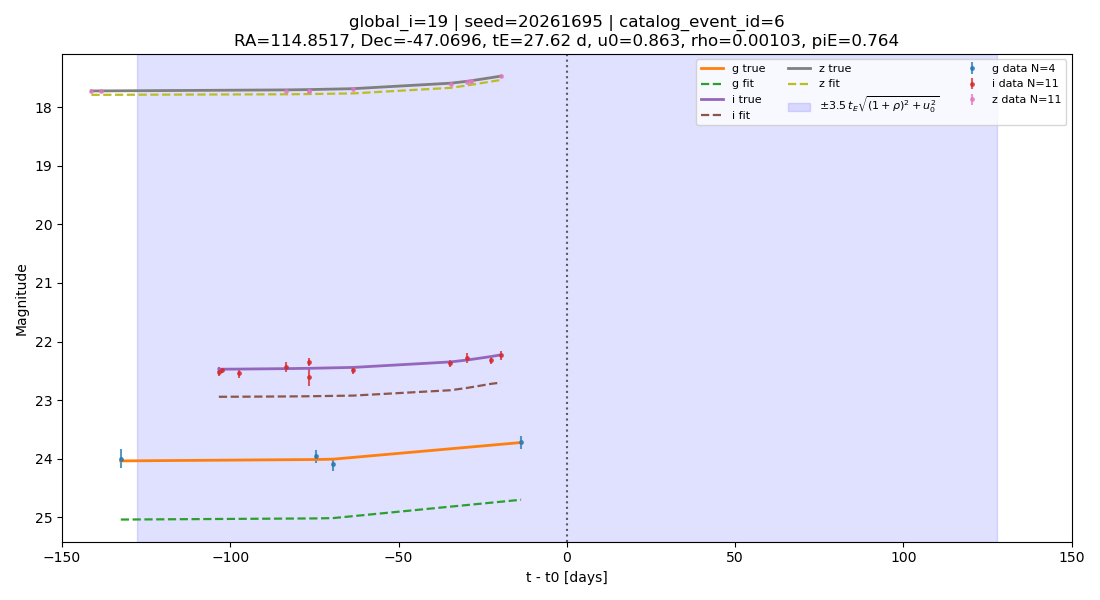

In [2]:
%matplotlib ipympl
plt.close("all")

fig, ax, meta, curves, true_params, fit_results = plot_true_and_fit(
    global_i=19,
    model="FSPL",
    xlim_days=150,
    bands=["g", "r", "i", "z", "y"],
    save=False,
)

In [3]:
# Diagnóstico temporal del evento ya cargado
t0 = float(true_params["t0"])
tE = float(true_params["tE"])

for band in ["u", "g", "r", "i", "z", "y", "W149"]:
    if band not in curves or len(curves[band]) == 0:
        continue

    tbl = curves[band]
    t = tbl["time"].value if hasattr(tbl["time"], "value") else np.asarray(tbl["time"])
    dt = np.asarray(t) - t0

    print(
        f"{band:>4s}: "
        f"N={len(dt):3d}, "
        f"min(dt)={dt.min():8.2f}, "
        f"max(dt)={dt.max():8.2f}, "
        f"N(|dt|<tE)={np.sum(np.abs(dt) < tE):3d}, "
        f"N(dt<0)={np.sum(dt < 0):3d}, "
        f"N(dt>0)={np.sum(dt > 0):3d}"
    )

   g: N= 68, min(dt)=-3429.38, max(dt)=  -13.59, N(|dt|<tE)=  1, N(dt<0)= 68, N(dt>0)=  0
   r: N=  1, min(dt)=-3116.38, max(dt)=-3116.38, N(|dt|<tE)=  0, N(dt<0)=  1, N(dt>0)=  0
   i: N=133, min(dt)=-3434.26, max(dt)=  -19.61, N(|dt|<tE)=  2, N(dt<0)=133, N(dt>0)=  0
   z: N=102, min(dt)=-3468.25, max(dt)=  -19.58, N(|dt|<tE)=  1, N(dt<0)=102, N(dt>0)=  0
   y: N=  1, min(dt)=-3423.38, max(dt)=-3423.38, N(|dt|<tE)=  0, N(dt<0)=  1, N(dt>0)=  0


In [4]:
import pandas as pd
from pathlib import Path

RUN = Path("/home/anibal/ulensing_degenerate_models/Parallax_LSST/runs/LSSTMONTS_xi_baseline_v5p3p5_catalogBlending_FSPLparallax_fitFSPLNoPiE_test")

s = pd.read_parquet(RUN / "logs/run_summary.parquet")

cols = [
    "global_i",
    "catalog_event_id",
    "t0_origin",
    "t0_reference_jd",
    "t0_reference_mjd",
    "t0_catalog_days",
    "t0_jd",
    "t0_jd_original_global_zero",
    "fit_n_points_total",
]

display(s[[c for c in cols if c in s.columns]])

,global_i,catalog_event_id,t0_origin,t0_reference_jd,t0_reference_mjd,t0_catalog_days,t0_jd,t0_jd_original_global_zero,fit_n_points_total
0,0,22,first_maf_timestamp,2.461338e+06,61337.332970,858.98013,2.462197e+06,2.461272e+06,334
1,1,22,first_maf_timestamp,2.461338e+06,61337.332970,1726.31435,2.463064e+06,2.462139e+06,547
2,2,10,first_maf_timestamp,2.461338e+06,61337.328091,1697.16950,2.463035e+06,2.462110e+06,426
3,3,25,first_maf_timestamp,2.461338e+06,61337.328091,2769.46856,2.464107e+06,2.463182e+06,535
4,4,12,first_maf_timestamp,2.461338e+06,61337.328091,1367.28885,2.462705e+06,2.461780e+06,407
5,5,20,first_maf_timestamp,2.461338e+06,61337.343376,2427.98000,2.463766e+06,2.462841e+06,440
6,6,22,first_maf_timestamp,2.461338e+06,61337.343376,2701.98697,2.464040e+06,2.463115e+06,529
7,7,15,first_maf_timestamp,2.461338e+06,61337.328091,3325.66169,2.464663e+06,2.463739e+06,338
8,8,6,first_maf_timestamp,2.461338e+06,61337.343376,2325.12854,2.463663e+06,2.462738e+06,477
9,9,30,first_maf_timestamp,2.461338e+06,61337.343811,218.51836,2.461556e+06,2.460632e+06,333


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bandas a mostrar
BANDS_GRID = ["g", "r", "i", "z", "y"]

# Colores fijos para no mezclar bandas
COLORS = {
    "g": "tab:green",
    "r": "tab:red",
    "i": "tab:purple",
    "z": "tab:gray",
    "y": "tab:olive",
    "u": "tab:blue",
    "W149": "tab:cyan",
}

def plot_one_event_on_axis(ax, global_i, model="FSPL", xlim_days=150, bands=BANDS_GRID):
    meta, curves, true_params, fit_results, true_model, fit_model, fit_params, *_ = load_event_bundle(
        global_i,
        model=model,
    )

    t0 = float(true_params["t0"])
    tE = float(true_params["tE"])

    for band in bands:
        data = _curve_array(curves, band)

        if len(data) == 0:
            continue

        t = data[:, 0]
        m = data[:, 1]
        e = data[:, 2]

        mask = (t >= t0 - xlim_days) & (t <= t0 + xlim_days)

        if mask.sum() == 0:
            continue

        color = COLORS.get(band, None)

        # Datos
        ax.errorbar(
            t[mask] - t0,
            m[mask],
            yerr=e[mask],
            fmt=".",
            ms=3,
            alpha=0.65,
            color=color,
        )

        # Modelo verdadero
        tel_true = _get_tel(true_model, band)
        if tel_true is not None:
            tt = np.asarray(_to_array(tel_true.lightcurve["time"]), dtype=float)
            ftrue = true_model.compute_the_microlensing_model(
                tel_true,
                true_params,
            )["photometry"]
            mtrue = mag(ZP[band], ftrue)

            mask_true = (tt >= t0 - xlim_days) & (tt <= t0 + xlim_days)
            if mask_true.sum() > 0:
                order = np.argsort(tt[mask_true])
                ax.plot(
                    tt[mask_true][order] - t0,
                    mtrue[mask_true][order],
                    lw=1.5,
                    color=color,
                )

        # Modelo ajustado
        tel_fit = _get_tel(fit_model, band)
        if tel_fit is not None:
            tt = np.asarray(_to_array(tel_fit.lightcurve["time"]), dtype=float)
            ffit = fit_model.compute_the_microlensing_model(
                tel_fit,
                fit_params,
            )["photometry"]
            mfit = mag(ZP[band], ffit)

            mask_fit = (tt >= t0 - xlim_days) & (tt <= t0 + xlim_days)
            if mask_fit.sum() > 0:
                order = np.argsort(tt[mask_fit])
                ax.plot(
                    tt[mask_fit][order] - t0,
                    mfit[mask_fit][order],
                    "--",
                    lw=1.2,
                    color=color,
                )

    ax.axvline(0, color="k", ls=":", alpha=0.5)
    ax.set_xlim(-xlim_days, xlim_days)
    ax.invert_yaxis()

    ax.set_title(
        f"global_i={global_i}, event_id={meta.get('catalog_event_id')}\n"
        f"tE={meta.get('tE_catalog_days'):.1f} d, "
        f"u0={meta.get('u0'):.2g}, "
        f"piE={meta.get('piE'):.2g}",
        fontsize=9,
    )

    return meta


def plot_grid_events(global_ids, model="FSPL", xlim_days=150, bands=BANDS_GRID):
    fig, axes = plt.subplots(
        5,
        2,
        figsize=(14, 16),
        sharex=False,
        sharey=False,
    )

    axes = axes.ravel()

    for ax, gid in zip(axes, global_ids):
        try:
            plot_one_event_on_axis(
                ax,
                global_i=int(gid),
                model=model,
                xlim_days=xlim_days,
                bands=bands,
            )
        except Exception as e:
            ax.text(
                0.5,
                0.5,
                f"global_i={gid}\n{repr(e)}",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_axis_off()

    for ax in axes[len(global_ids):]:
        ax.set_axis_off()

    for ax in axes:
        if ax.has_data():
            ax.set_xlabel("t - t0 [days]")
            ax.set_ylabel("mag")

    # Leyenda global
    handles = []
    labels = []

    for band in bands:
        color = COLORS.get(band, None)
        h_data = plt.Line2D([], [], marker=".", ls="", color=color, label=f"{band} data")
        h_true = plt.Line2D([], [], ls="-", color=color, label=f"{band} true")
        h_fit = plt.Line2D([], [], ls="--", color=color, label=f"{band} fit")
        handles.extend([h_data, h_true, h_fit])
        labels.extend([f"{band} data", f"{band} true", f"{band} fit"])

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=5,
        fontsize=9,
        bbox_to_anchor=(0.5, 1.01),
    )

    fig.tight_layout(rect=[0, 0, 1, 0.98])
    return fig, axes

check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
check_event  : Everything looks fine...
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
check_event  : Everything looks fine...
check_event  : Everything looks fine...


/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 39 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 39 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utcut1" yielded 39 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: Er

Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
check_event  : Everything looks fine...
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
check_event  : Everything looks fine...
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
check_event  : Everything looks fine...
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Para

/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 50 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 50 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utcut1" yielded 50 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: Er

check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
check_event  : Everything looks fine...
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
check_event  : Everything looks fine...


...

/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 34 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 34 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utcut1" yielded 34 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: Er

check_event  : Everything looks fine...
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
check_event  : Everything looks fine...
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
check_event  : Everything looks fine...


/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 47 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 47 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utcut1" yielded 47 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: Er

check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope u: SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
check_event  : Everything looks fine...
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
check_event  : Everything looks fine...


/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 34 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 34 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utcut1" yielded 34 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/anibal/anaconda3/envs/roman_rubin/lib/python3.11/site-packages/erfa/core.py:133: Er

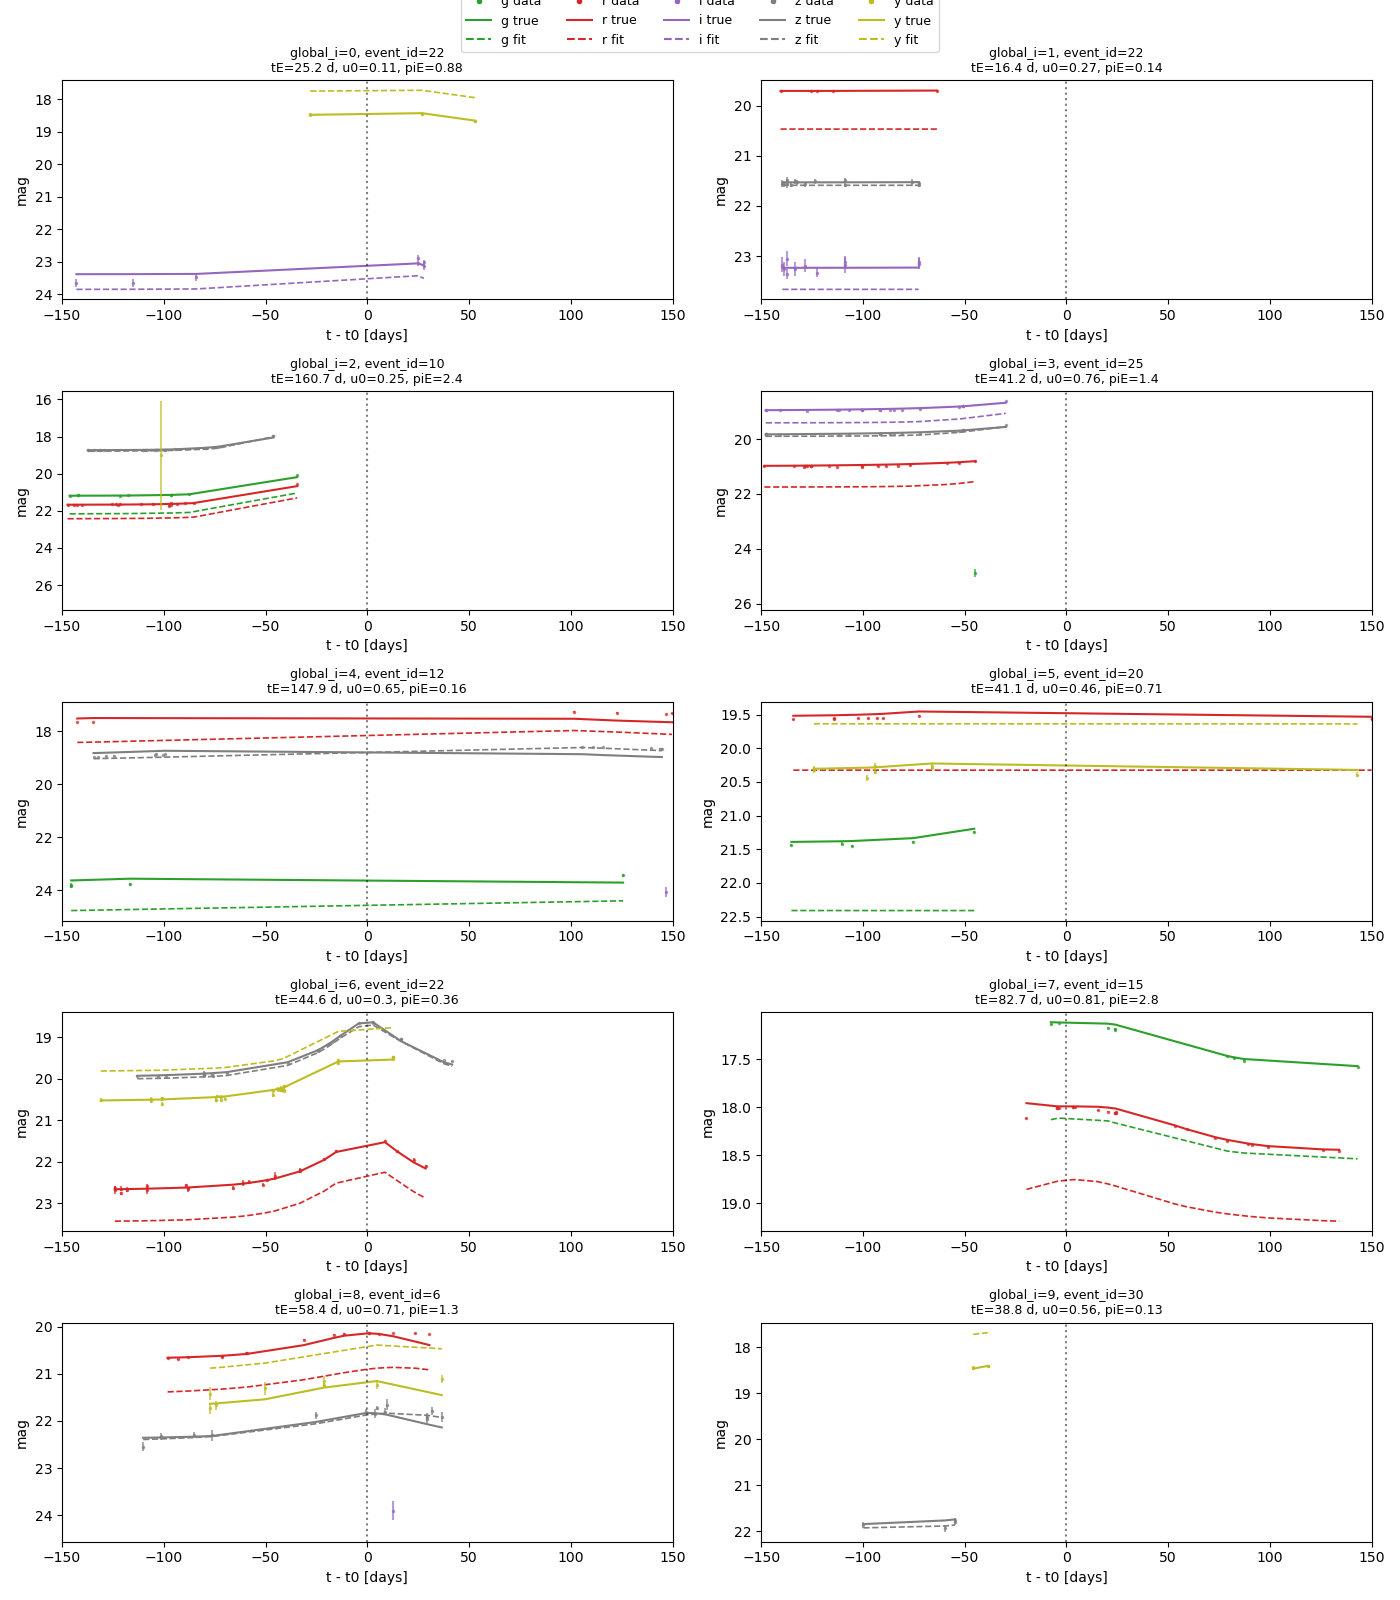

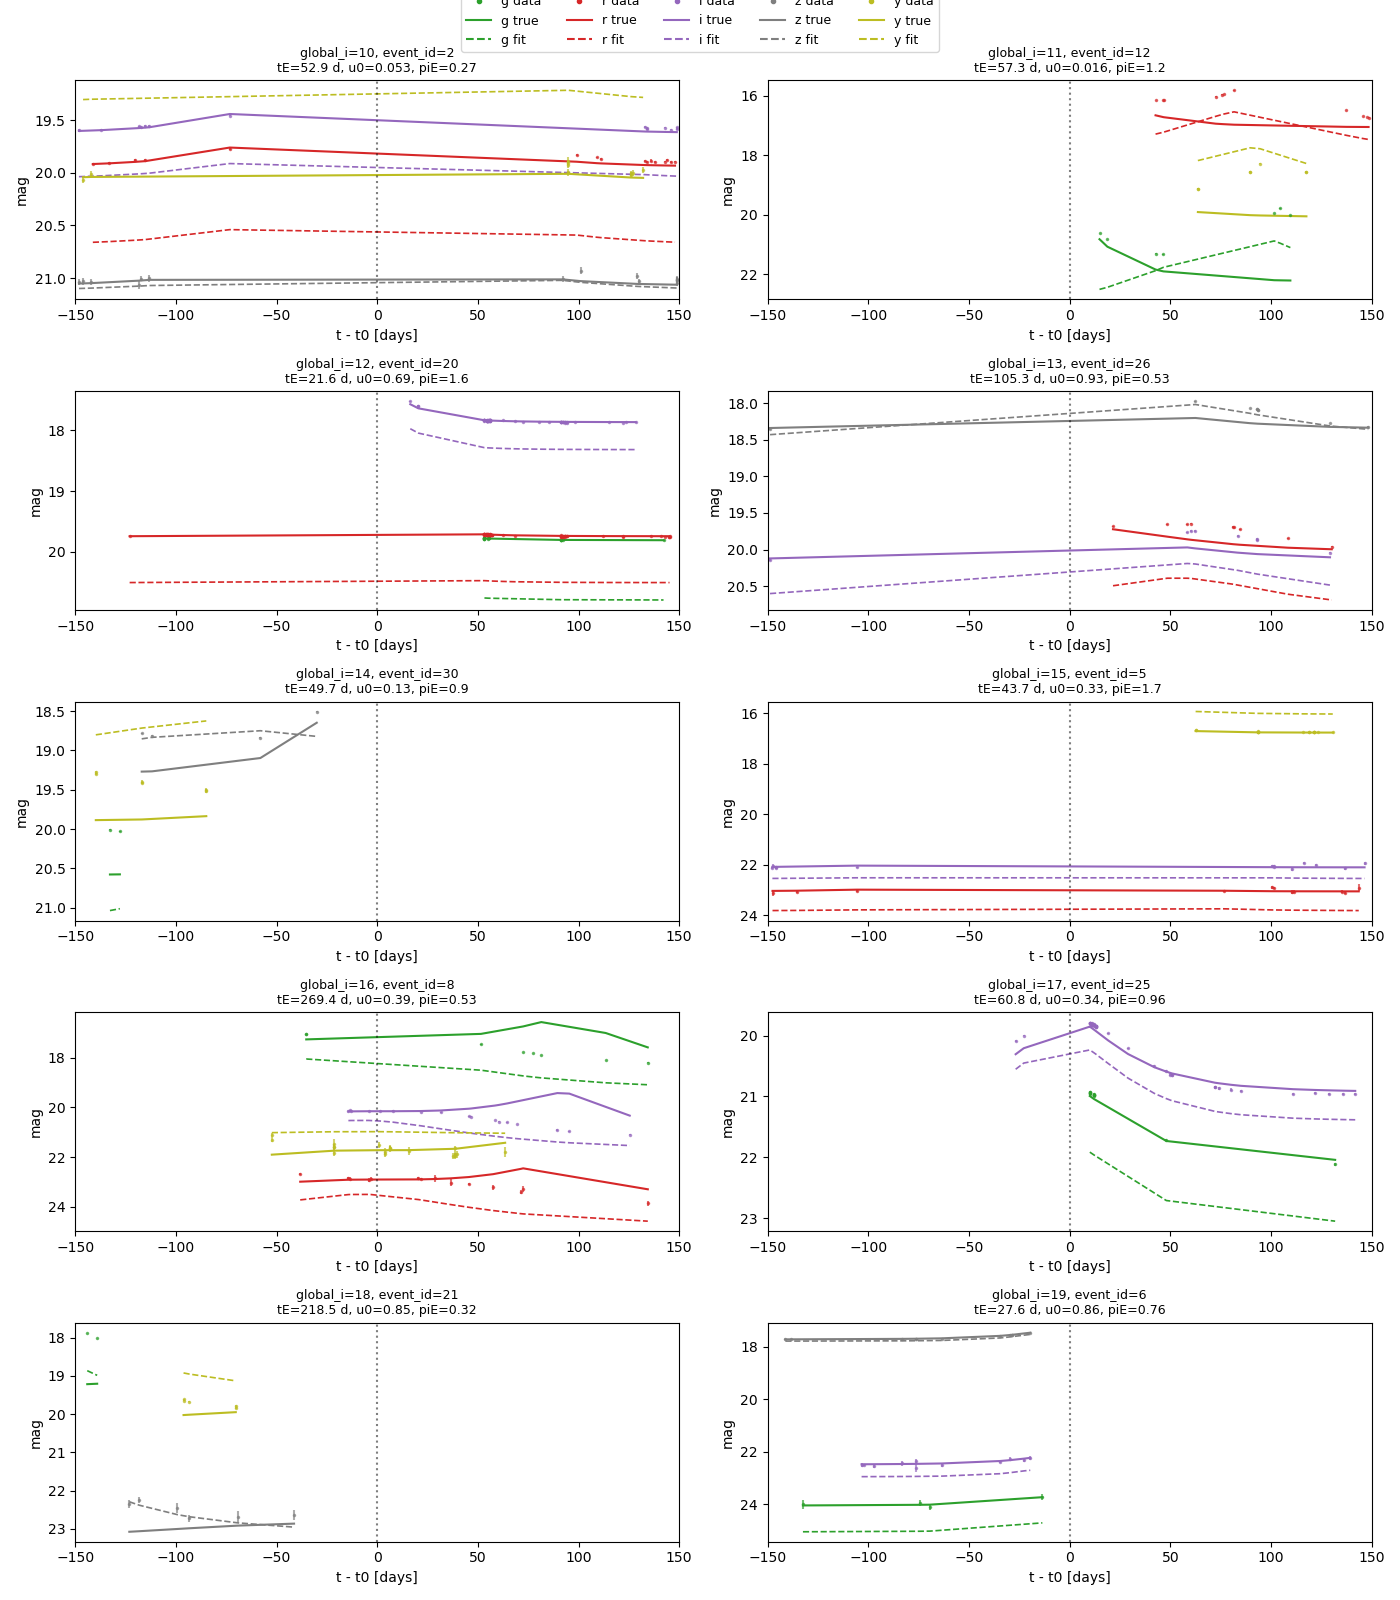

In [7]:
%matplotlib ipympl
plt.close("all")

summary = pd.read_parquet(RUN / "logs" / "run_summary.parquet")
ok_ids = summary.loc[summary["status"] == "ok", "global_i"].astype(int).tolist()

# Primeros 10 eventos
fig1, axes1 = plot_grid_events(
    ok_ids[:10],
    model="FSPL",
    xlim_days=150,
    bands=["g", "r", "i", "z", "y"],
)

# Siguientes 10 eventos
fig2, axes2 = plot_grid_events(
    ok_ids[10:20],
    model="FSPL",
    xlim_days=150,
    bands=["g", "r", "i", "z", "y"],
)